In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

In [2]:
data_dir = "/home/patricka/Projects/DataScienceAndMachineLearning/Data/"

df = pd.read_csv(data_dir + 'AirQualityUCI.csv', sep = ";")
df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,"3,1",1314.0,-200.0,"13,5",1101.0,472.0,539.0,190.0,1374.0,1729.0,"21,9","29,3","0,7568"
9353,04/04/2005,11.00.00,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119"
9354,04/04/2005,12.00.00,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406"
9355,04/04/2005,13.00.00,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139"


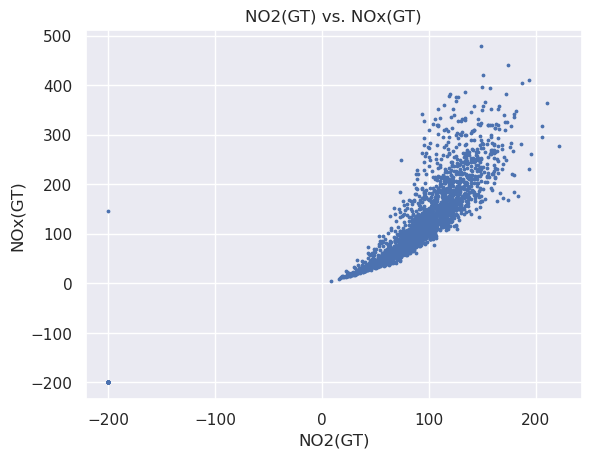

In [3]:
training_cutoff = 2500
df_slice = df.iloc[0:training_cutoff, :]
X = df_slice['NO2(GT)']
y = df_slice['NOx(GT)']
plt.xlabel("NO2(GT)")
plt.ylabel("NOx(GT)")
plt.title(f"NO2(GT) vs. NOx(GT)")
plt.scatter(X, y, s = 3)
plt.show()

In [ ]:
class PolynomialRegressionNeuron():
    def __init__(self, degree = 2):
        self.degree = degree
        
    def train(self, X, y, eta = 0.0001, epochs=100):
        self.n = X.shape[0]
        self.weights = np.random.rand(self.degree)
        self.bias = np.random.rand()
        errors = np.empty(epochs)
        for epoch in range(epochs):
            y_hats = np.empty(self.n)
            for i in range(self.n):
                y_hats[i] = self.predict(X[i])
            for i in range(self.n):
                for j in range(self.degree):
                    self.weights[j] += -eta**(j+1) * (y_hats[i] - y[i]) * X[i]**(j+1) / self.n
                self.bias += -eta * (y_hats[i] - y[i]) / self.n
            errors[epoch] = (self.cost(y, y_hats))
        return errors
    
    def cost(self, y, y_hat):
        cost = 0.0
        for i in range(self.n):
            cost += (y_hat[i] - y[i])**2
        cost /= 2.0*self.n
        return cost

    def predict(self, x):
        return sum(self.weights[i] * x**(i+1) for i in range(self.degree)) + self.bias

In [53]:
neuron = PolynomialRegressionNeuron()
errors = neuron.train(X, y, eta = 2e-5)
print(errors[-10:])

[795.06487768 795.06422982 795.06358197 795.06293414 795.06228632
 795.06163851 795.06099071 795.06034292 795.05969514 795.05904736]


Minimum error: 1220.461646724969


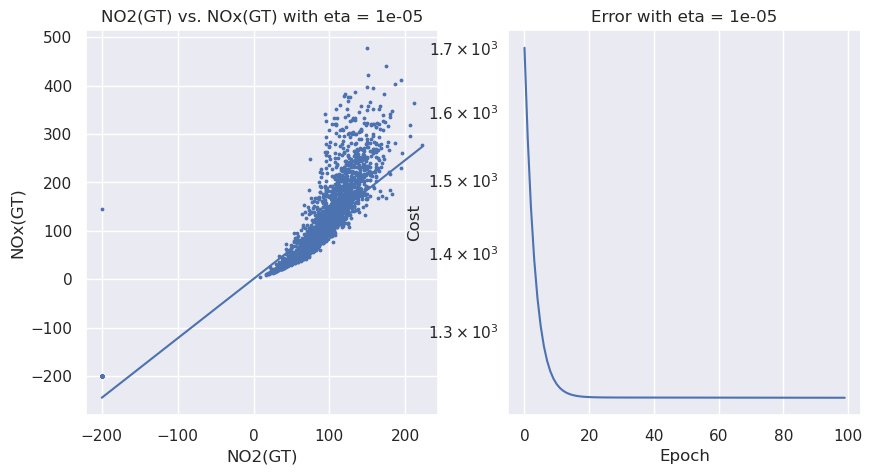

In [54]:
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
t = np.linspace(min(X), max(X), 1000)

Neuron = PolynomialRegressionNeuron(degree = 1)
neuron_eta = 1e-5
errors = Neuron.train(X, y, eta = neuron_eta, epochs = 100)
t_y = [Neuron.predict(t_i) for t_i in t]
axs[0].plot(t, t_y)
axs[0].set_xlabel("NO2(GT)")
axs[0].set_ylabel("NOx(GT)")
axs[0].set_title(f"NO2(GT) vs. NOx(GT) with eta = {neuron_eta}")
axs[0].scatter(X, y, s = 3)

axs[1].semilogy(errors)
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Cost")
axs[1].set_title(f"Error with eta = {neuron_eta}")

print(f"Minimum error: {min(errors)}")

Minimum error: 792.179212538045


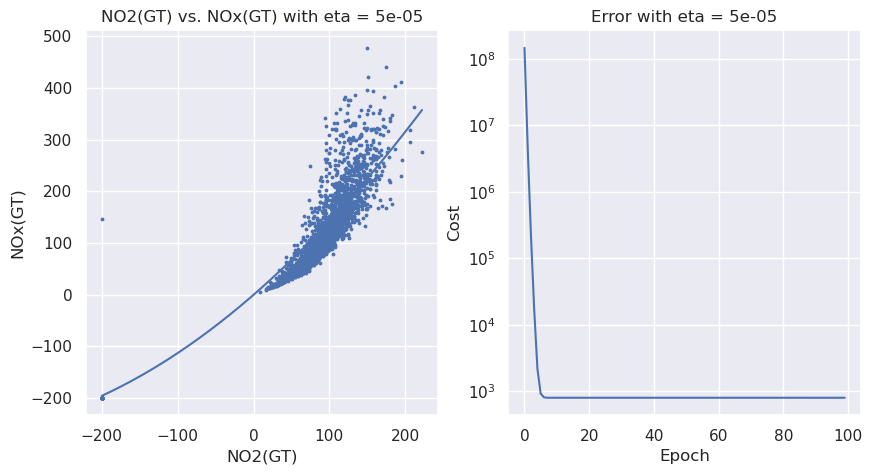

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
t = np.linspace(min(X), max(X), 1000)

Neuron = PolynomialRegressionNeuron(degree = 2)
neuron_eta = 5e-5
errors = Neuron.train(X, y, eta = neuron_eta, epochs = 100)
t_y = [Neuron.predict(t_i) for t_i in t]
axs[0].plot(t, t_y)
axs[0].set_xlabel("NO2(GT)")
axs[0].set_ylabel("NOx(GT)")
axs[0].set_title(f"NO2(GT) vs. NOx(GT) with eta = {neuron_eta}")
axs[0].scatter(X, y, s = 3)

axs[1].semilogy(errors)
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Cost")
axs[1].set_title(f"Error with eta = {neuron_eta}")

print(f"Minimum error: {min(errors)}")

Minimum error: 887.6924681878243


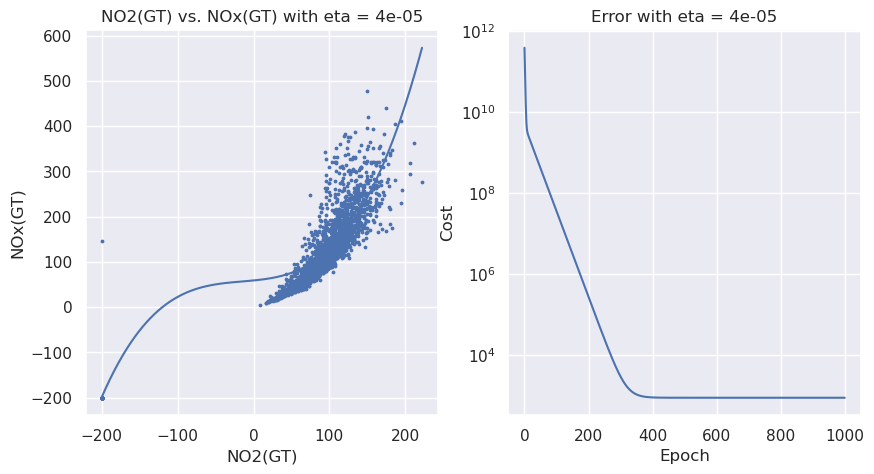

In [65]:
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
t = np.linspace(min(X), max(X), 1000)

Neuron = PolynomialRegressionNeuron(degree = 3)
neuron_eta = 4e-5
errors = Neuron.train(X, y, eta = neuron_eta, epochs = 1000)
t_y = [Neuron.predict(t_i) for t_i in t]
axs[0].plot(t, t_y)
axs[0].set_xlabel("NO2(GT)")
axs[0].set_ylabel("NOx(GT)")
axs[0].set_title(f"NO2(GT) vs. NOx(GT) with eta = {neuron_eta}")
axs[0].scatter(X, y, s = 3)

axs[1].semilogy(errors)
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Cost")
axs[1].set_title(f"Error with eta = {neuron_eta}")

print(f"Minimum error: {min(errors)}")